# Intro

$x_t$ is a single video frame (image at time t)

$$
z_t = f_{\theta}(x_t)
$$

$f_{\theta}$ = CNN encoder (neural network with parameters $\theta$)  
*Input:* image $x_t$  
*Output:* latent vector $z_t$ (compressed numeric representation of the frame)

$$
z_{t+1} = f_{\theta}(x_{t+1})
$$

Same CNN encoder  
*Input:* next image $x_{t+1}$  
*Output:* true next latent representation $z_{t+1}$

$$
\hat{a}_t = g_{\phi}(z_t, z_{t+1})
$$

$g_{\phi}$ = Action Inference Network (MLP with parameters $\phi$)  
*Input:* current latent $z_t$ and next latent $z_{t+1}$  
*Output:* inferred action $\hat{a}_t$ that best explains transition

$$
\hat{z}_{t+1} = h_{\psi}(z_t, \hat{a}_t)
$$

$h_{\psi}$ = Dynamics model (MLP or RNN with parameters $\psi$)  
*Input:* current latent $z_t$ and inferred action $\hat{a}_t$  
*Output:* predicted next latent $\hat{z}_{t+1}$

$$
\hat{x}_{t+1} = d_{\omega}(\hat{z}_{t+1})
$$

$d_{\omega}$ = Decoder network (neural network with parameters $\omega$)  
*Input:* predicted latent $\hat{z}_{t+1}$  
*Output:* predicted next image $\hat{x}_{t+1}$

$$
L_{pixel} = \| x_{t+1} - \hat{x}_{t+1} \|^2
$$

Pixel reconstruction loss (MSE)  
*Input:* true frame $x_{t+1}$ and predicted frame $\hat{x}_{t+1}$  
*Output:* scalar reconstruction error

$$
L_{latent} = \| z_{t+1} - \hat{z}_{t+1} \|^2
$$

Latent consistency loss (MSE)
*Input:* true latent $z_{t+1}$ and predicted latent $\hat{z}_{t+1}$  
*Output:* scalar latent error

$$
L = L_{pixel} + \alpha L_{latent}
$$

Total training loss minimized during learning

# Data

## Split Videos into Images

We convert raw rollout videos into a dataset of frames:

$$
\text{video} \;\rightarrow\; \{x_1, x_2, \dots, x_T\}, 
\quad x_t \in \mathbb{R}^{1 \times 84 \times 84}
$$

Each frame is processed as:

$$
x_t = \text{Resize}_{84 \times 84}\big(\text{Gray}(frame_t)\big)
$$

Frames are stored per episode:

$$
\text{data/frames}/e/\{x_1, x_2, \dots, x_T\}
$$

From this, we construct a dataset of transition pairs:

$$
\mathcal{D} = \{(x_t, x_{t+1})\}
$$

The dataset is then serialized:

$$
\mathcal{D} \;\rightarrow\; \text{data/dataset/dataset.pt}
$$

This removes video decoding overhead and ensures fast, consistent tensor inputs during training.


In [1]:
import cv2
import os

# VIDEO_DIR = "../Donor/videos"
# SAVE_DIR = "data/frames"

# # ustaw cwd tylko jeśli odpalasz jako .py
# if "__file__" in globals():
#     os.chdir(os.path.dirname(os.path.abspath(__file__)))

# os.makedirs(SAVE_DIR, exist_ok=True)

# video_files = sorted([f for f in os.listdir(VIDEO_DIR) if f.endswith(".mp4")])

# for vid_idx, video_name in enumerate(video_files):

#     print(f"[PROCESSING] {video_name}")

#     video_path = os.path.join(VIDEO_DIR, video_name)
#     cap = cv2.VideoCapture(video_path)

#     episode_dir = os.path.join(SAVE_DIR, str(vid_idx))
#     os.makedirs(episode_dir, exist_ok=True)

#     frame_id = 0

#     while True:
#         ret, frame = cap.read()
#         if not ret:
#             break

#         frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
#         frame = cv2.resize(frame, (84, 84))

#         save_path = os.path.join(episode_dir, f"{frame_id}.png")
#         cv2.imwrite(save_path, frame)

#         frame_id += 1

#     cap.release()

#     print(f"[DONE] episode {vid_idx} → {frame_id} frames")

# print("ALL DONE")

## Dataset

We construct a dataset of transition pairs from preprocessed frames.

Each episode is a sequence:
$$
\{x_1, x_2, \dots, x_T\}
$$

From this, we build training samples:
$$
(x_t, x_{t+1}), \quad t = 1, \dots, T-1
$$

Each frame is represented as:
$$
x_t \in \mathbb{R}^{1 \times 84 \times 84}
$$

The full dataset is a flat collection of tuples:
$$
\mathcal{D} = \{(x_t, x_{t+1})\}
$$

Episode boundaries are not explicitly modeled.  
Temporal consistency is preserved locally through $(x_t, x_{t+1})$, which is sufficient for learning dynamics.

The fundamental learning signal is the transition:
$$
x_t \rightarrow x_{t+1}
$$

The dataset is serialized and stored as:
$$
\mathcal{D} \;\rightarrow\; \text{data/dataset/dataset.pt}
$$

This formulation enables learning action-consistent representations directly from visual state transitions.


## Create

In [2]:
# import os
# import torch
# from torch.utils.data import Dataset
# from PIL import Image
# import torchvision.transforms as T

# # safe cwd
# if "__file__" in globals():
#     os.chdir(os.path.dirname(os.path.abspath(__file__)))


# class VideoDataset(Dataset):
#     def __init__(self, input_dir, output_path=None):
#         self.samples = []
#         self.transform = T.ToTensor()

#         total_pairs = 0

#         for episode in sorted(os.listdir(input_dir)):
#             episode_path = os.path.join(input_dir, episode)

#             if not os.path.isdir(episode_path):
#                 continue

#             frames = sorted(
#                 os.listdir(episode_path),
#                 key=lambda x: int(x.split(".")[0])
#             )

#             num_pairs = len(frames) - 1

#             for i in range(num_pairs):
#                 f1 = os.path.join(episode_path, frames[i])
#                 f2 = os.path.join(episode_path, frames[i+1])

#                 x_t  = Image.open(f1).convert("L")
#                 x_t1 = Image.open(f2).convert("L")

#                 x_t  = self.transform(x_t)
#                 x_t1 = self.transform(x_t1)

#                 self.samples.append((x_t, x_t1))

#             total_pairs += num_pairs
#             print(f"[DATASET] episode {episode} → {num_pairs} pairs")

#         print(f"[DATASET] total pairs: {total_pairs}")

#         # save
#         if output_path is not None:
#             os.makedirs(os.path.dirname(output_path), exist_ok=True)
#             torch.save(self.samples, output_path)
#             print(f"[SAVED] dataset → {output_path}")

#     def __len__(self):
#         return len(self.samples)

#     def __getitem__(self, idx):
#         return self.samples[idx]

In [3]:
# dataset = VideoDataset(
#     input_dir="data/frames",
#     output_path="data/dataset/dataset.pt"
# )

## Import

In [4]:
import torch
from torch.utils.data import Dataset

class DownloadVideoDataset(Dataset):
    def __init__(self, dataset_path):
        print(f"[LOADING] {dataset_path}")
        self.samples = torch.load(dataset_path)
        print(f"[LOADED] {len(self.samples)} samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

In [5]:
dataset = DownloadVideoDataset("data/dataset/dataset.pt")

[LOADING] data/dataset/dataset.pt
[LOADED] 13661 samples


## Explore

In [6]:
from IPython.display import display, Math

display(Math(f"We\\ have\\ {len(dataset)}\\ tuples:\\ (x_t, x_{{t+1}})"))

<IPython.core.display.Math object>

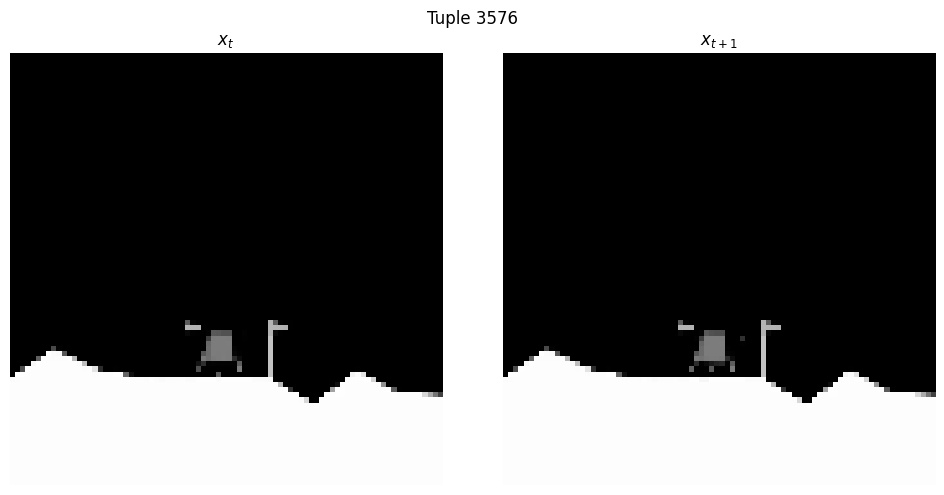

In [7]:
import numpy as np
import matplotlib.pyplot as plt

rand_img = np.random.randint(len(dataset))

x_t0 = dataset[rand_img][0]
x_t1 = dataset[rand_img][1]

fig, axs = plt.subplots(1,2,figsize= (10,5))

axs[0].imshow(x_t0.squeeze(), cmap = 'grey')
axs[0].set_title('$x_t$')
axs[1].imshow(x_t1.squeeze(), cmap = 'grey')
axs[1].set_title('$x_{t+1}$')

for i in range(2):
    axs[i].axis(False)

plt.suptitle(f'Tuple {rand_img}')
plt.tight_layout()
plt.show()


## DataLoader

In [8]:
from torch.utils.data import DataLoader

def get_dataloader(dataset, batch_size=64, shuffle=True, num_workers=0):
    print(f"[DATALOADER] batch_size={batch_size}")

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,  # w notebooku = 0
        pin_memory=True
    )

In [9]:
dataloader = get_dataloader(dataset)

for x_t, x_t1 in dataloader:
    print(x_t.shape)
    break

[DATALOADER] batch_size=64
torch.Size([64, 1, 84, 84])


/Users/adriankazi/miniconda3/envs/dl-video-learning/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
